In [2]:
import pandas as pd
import importlib
import data_audit

importlib.reload(data_audit)



df = pd.read_csv("restaurant_clf.csv")

# url: URL адрес на ресторанта в Restaurant GPT.
# address: Адрес на ресторанта.
# name: Име на ресторанта.
# online_order: Дали е налична опция за онлайн поръчка.
# book_table: Дали е налична опция за онлайн резервация на маса.
# votes: Общ брой гласове/оценки за ресторанта.
# phone: Телефонен номер на ресторанта.
# location: Кварталът, в който се намира ресторантът.
# rest_type: Тип на обекта.
# dish_liked: Списък с ястия, харесвани от клиентите.
# cuisines: Типове кухни, обслужвани от ресторанта.
# approx_cost(for two people): Приблизителна цена за хранене на двама души.
# reviews_list: Списък с ревюта и оценки от клиенти.
# menu_item: Списък с налични елементи от менюто.
# listed_in(type): Тип на хранене.
# listed_in(city): Зоната на града, в която е разположен ресторантът (обикновено по-голяма област от "location").
# rate: Общата агрегирана оценка на ресторанта.


In [ ]:
data_audit.create_data_audit(df.drop(columns=['Unnamed: 0','url', 'address', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']), bar_chart_cols=['online_order', 'book_table', 'location', 'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)'], hue_column=None)

In [3]:
#Preprocessing data

from sklearn.preprocessing import OneHotEncoder

#Making rates to be numbers
df['rate_clean'] = (
    df['rate']
      .replace('-', pd.NA)     # "-" = missing
      .replace('NEW', pd.NA)   # "NEW" = missing rating
      .str.replace(' ', '', regex=False)
      .str.split('/')
      .str[0]
      .pipe(pd.to_numeric, errors='coerce')
)

print('preprocessed rates')

#creating target column
median_rate = df['rate_clean'].median()
df['above_median_rate'] = (df['rate_clean'] > median_rate).astype(int)

print('created target column')

#Mapping yes/no to 1/0
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

print('mapped online_order and book_table to 0/1')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['location'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['location'])], axis=1)

# print('one-hot encoded location')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['name'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['name'])], axis=1)

# print('one-hot encoded name')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['phone'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['phone'])], axis=1)

# print('one-hot encoded phone')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(type)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(type)'])], axis=1)

# print('one-hot encoded listed_in(type)')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(city)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(city)'])], axis=1)

# print('one-hot encoded listed_in(city)')

single_cat_cols = ['location', 'name', 'phone', 'listed_in(city)', 'listed_in(type)']

ohe = OneHotEncoder(drop='first', sparse_output=True, dtype=int)

ohe_matrix = ohe.fit_transform(df[single_cat_cols])

from scipy.sparse import csr_matrix
import numpy as np

def list_to_sparse(df_list, prefix=None):
    """
    Convert a Series of lists (multi-label) into a CSR sparse matrix.
    """
    # Create mapping: category → column index
    unique_values = sorted({item for sublist in df_list for item in sublist})
    col_index = {cat: i for i, cat in enumerate(unique_values)}

    # Build COO components
    rows = []
    cols = []
    data = []

    for row_idx, items in enumerate(df_list):
        for item in items:
            rows.append(row_idx)
            cols.append(col_index[item])
            data.append(1)

    # Convert to sparse CSR matrix
    mat = csr_matrix((data, (rows, cols)),
                     shape=(len(df_list), len(unique_values)),
                     dtype=int)
    return pd.DataFrame.sparse.from_spmatrix(mat, columns=unique_values)


rest_type = list_to_sparse(df, 'rest_type')

print('one-hot encoded rest_type')

dish_liked = list_to_sparse(df, 'dish_liked')

print('one-hot encoded dish_liked')

cuisines = list_to_sparse(df, 'cuisines')

print('one-hot encoded cuisines')

menu_item = list_to_sparse(df, 'menu_item')

print('one-hot encoded menu_item')

preprocessed rates
created target column
mapped online_order and book_table to 0/1
one-hot encoded rest_type
one-hot encoded dish_liked
one-hot encoded cuisines
one-hot encoded menu_item


In [4]:
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rate_clean',
       'above_median_rate'],
      dtype='object')


In [5]:
y = df['above_median_rate']

ohe_df = pd.DataFrame.sparse.from_spmatrix(
    ohe_matrix,
    columns=ohe.get_feature_names_out(single_cat_cols)
)

df_sparse_all = pd.concat([
    ohe_df,
    rest_type,
    dish_liked,
    cuisines,
    menu_item
], axis=1)


X = pd.concat([
    df_sparse_all,
    df[['online_order', 'book_table', 'votes']]
], axis=1)



In [6]:
print(X.columns.size)

23964


The columns are too many, that's why we will do TruncatedSVD 
so that we can get what are the useful columns and we are not
using PCA, because it's not optimized for sparse matrices.

In [7]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1)
X_reduced = svd.fit_transform(X)

print(X_reduced.shape[0])

/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


51717


In [8]:
print(X_reduced.shape[1])

1


In [9]:
explained = svd.explained_variance_ratio_.sum()
print("Total variance preserved:", explained)

Total variance preserved: 0.9999925458181222


We are preserving 99.9993% of the variance, so we can be sure that we are preserving most of the information. I also tried doing it with 100
dimensions and it preserved 99.9997%, with 10 and got 99.9994%, with 5 and got 99.9994% and with 2 and got 99.9993%.

knn
logistic


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


cart
xgboost
catboost
0:	learn: 0.6793629	total: 51ms	remaining: 51ms
1:	learn: 0.6663281	total: 52.9ms	remaining: 0us
0:	learn: 0.6792720	total: 781us	remaining: 781us
1:	learn: 0.6662228	total: 1.28ms	remaining: 0us
0:	learn: 0.6792327	total: 796us	remaining: 796us
1:	learn: 0.6661367	total: 1.39ms	remaining: 0us
0:	learn: 0.6793071	total: 760us	remaining: 760us
1:	learn: 0.6664986	total: 1.27ms	remaining: 0us
0:	learn: 0.6792675	total: 699us	remaining: 699us
1:	learn: 0.6661328	total: 1.25ms	remaining: 0us
0:	learn: 0.6023202	total: 869us	remaining: 869us
1:	learn: 0.5386064	total: 2.23ms	remaining: 0us
0:	learn: 0.6027871	total: 803us	remaining: 803us
1:	learn: 0.5380808	total: 1.55ms	remaining: 0us
0:	learn: 0.6013218	total: 793us	remaining: 793us
1:	learn: 0.5394066	total: 1.41ms	remaining: 0us
0:	learn: 0.6016792	total: 696us	remaining: 696us
1:	learn: 0.5383918	total: 1.42ms	remaining: 0us
0:	learn: 0.6024890	total: 949us	remaining: 949us
1:	learn: 0.5375300	total: 2.08ms	remai

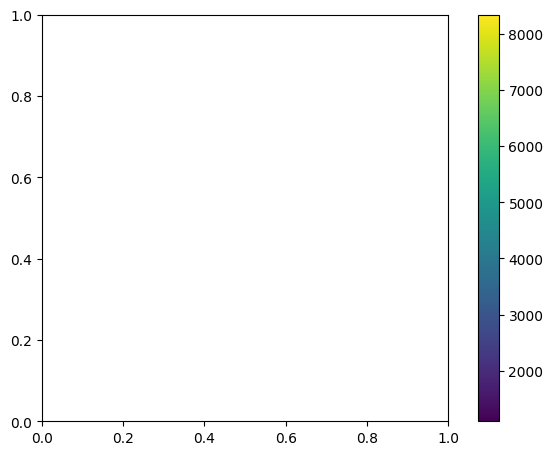

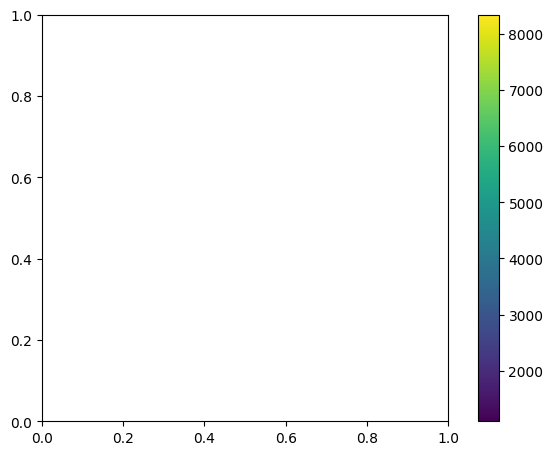

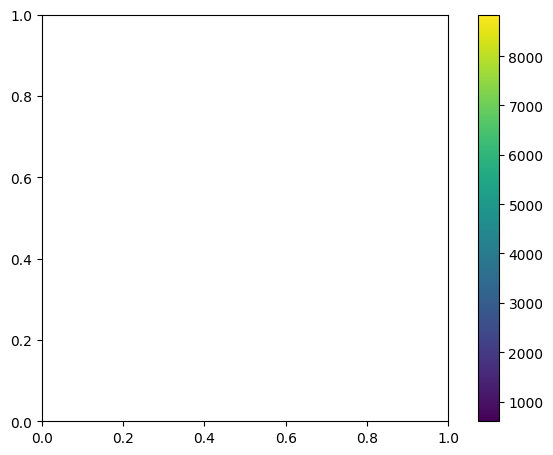

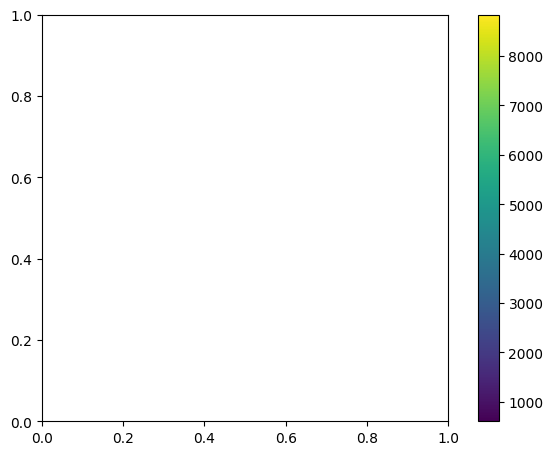

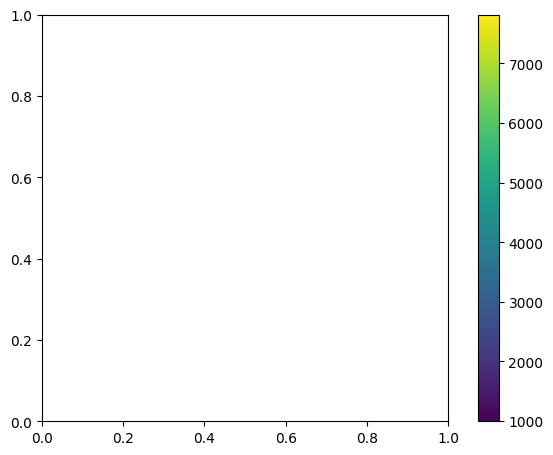

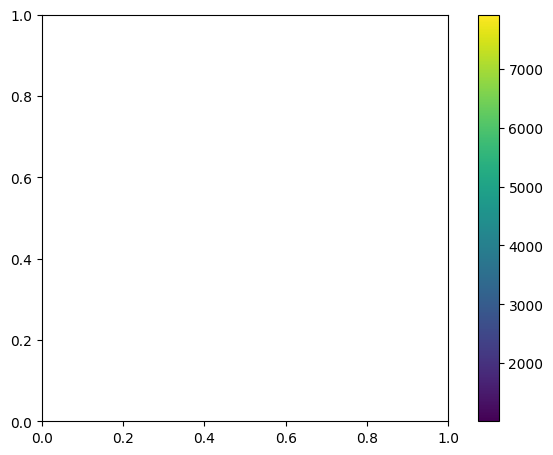

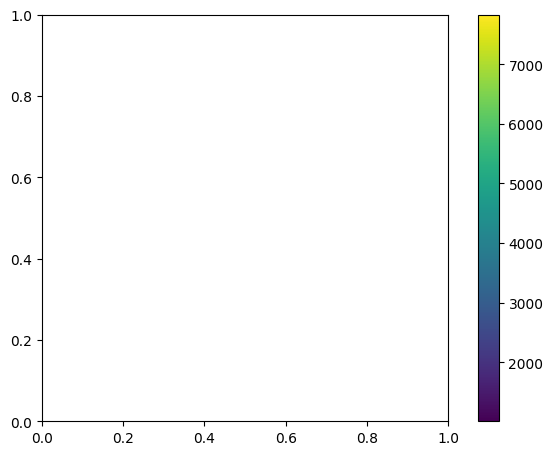

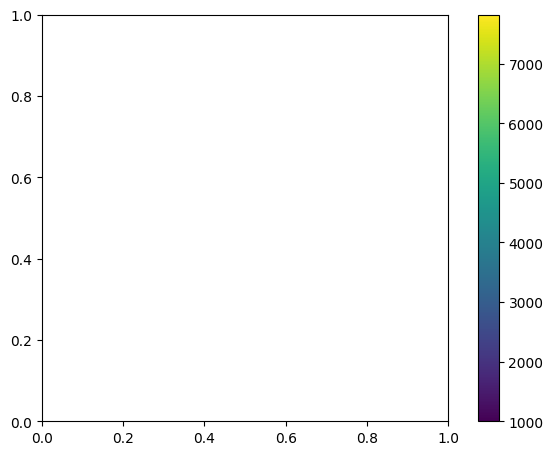

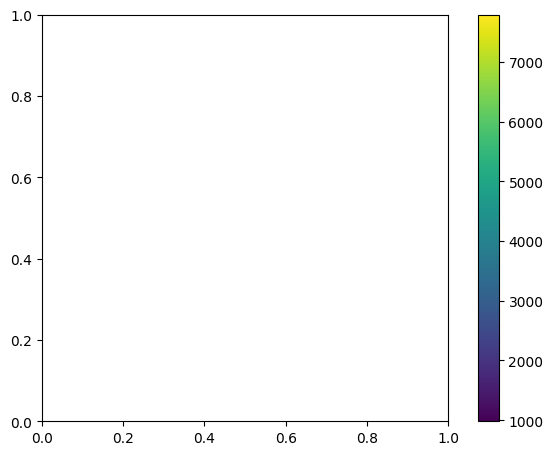

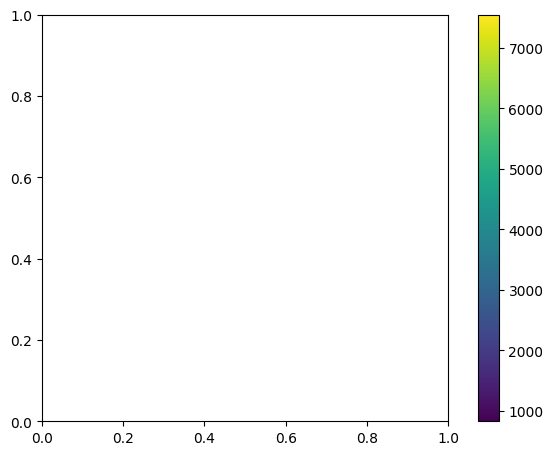

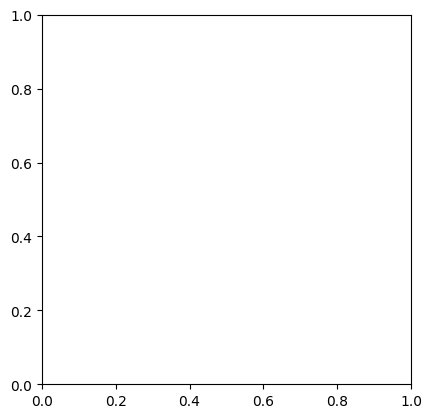

In [10]:
import classification
importlib.reload(classification)

X_reduced = pd.DataFrame(X_reduced)
classification.classify(X_options=[X_reduced], y=y, filename='./model_report.xlsx', diagrams='./diagrams', append=False)

